# Greenfield PV + BESS Optimization (LP-based)

This notebook finds the optimal PV and battery sizing for a greenfield project behind a **10 MW POI** using Linear Programming optimization.

## Analysis Approach
1. **Basic LP Optimization**: Optimal dispatch using `simulate_pv_bess_lp` (market prices only)
2. **Innovation Tender LP**: Optimal dispatch using `simulate_pv_bess_lp_innovationsausschreibung` (with Floating Market Premium)

## Key Constraints
- **Green Battery**: Can only charge from on-site PV generation
- **10 MW POI Limit**: Total export cannot exceed POI capacity
- **No Export at Negative Prices**

In [2]:
import sys
sys.path.insert(0, '../src')

# Clear cached modules
for mod_name in ['pv_battery_analysis', 'simulation', 'simulation_lp', 'economics', 'config']:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from preprocess import build_clean_dataset
from scipy.optimize import brentq
from typing import List

from config import (
    POI_CAPACITY_MW, CAPEX_PV_EUR_PER_KW, OPEX_PV_EUR_PER_KW_PER_YEAR,
    CAPEX_BESS_EUR_PER_KWH, OPEX_BESS_EUR_PER_KW_PER_YEAR,
    LIFETIME_PV_YEARS, LIFETIME_BESS_YEARS, WACC_PV_REAL, WACC_BESS_REAL,
    DEGRADATION_PV_PER_YEAR, PROJECT_LIFETIME_YEARS, BESS_REPLACEMENT_SHARE,
    BESS_ROUNDTRIP_EFF,
    INNOVATION_TENDER_MIN_BESS_POWER_RATIO, INNOVATION_TENDER_MIN_BESS_DURATION_H,
    INNOVATION_TENDER_PREMIUM_YEARS,
)
from simulation_lp import simulate_pv_bess_lp, simulate_pv_bess_lp_innovationsausschreibung
from simulation import simulate_single_tech_year
from economics import (
    build_cash_flows_pv_bess,
    combined_wacc_from_capex,
    npv,
)
from pv_battery_analysis import (
    PvBessResult, find_best_pv_bess_by_npv, results_to_dataframe,
)

plt.rcParams['figure.figsize'] = (12, 6)
print('Loaded!')

Loaded!


In [3]:
# Build cleaned dataset using shared preprocessing
project_root = Path.cwd()
if not (project_root / 'data_raw').exists():
    project_root = project_root.parent

df = build_clean_dataset(
    wind_path=project_root / 'data_raw' / 'wind_data.csv',
    pv_path=project_root / 'data_raw' / 'pv_data.csv',
    price_path=project_root / 'data_raw' / 'price_data.csv',
)
print(f"Data: {len(df)} hours, Price mean: {df['price_eur_per_mwh'].mean():.1f} EUR/MWh")


Data: 8760 hours, Price mean: 78.6 EUR/MWh


In [4]:
# Define grid evaluation function using  LP
def evaluate_pv_bess_grid_lp(
    df: pd.DataFrame,
    alpha_pv_values: List[float],
    gamma_values: List[float],
    batt_duration_h: float = 2.0,
    poi_capacity_mw: float = POI_CAPACITY_MW,
    solver: str = None,
    time_limit_seconds: int = 300,
) -> List[PvBessResult]:
    """Evaluate PV+BESS grid using LP optimization."""
    results: List[PvBessResult] = []
    
    for alpha_pv in alpha_pv_values:
        for gamma in gamma_values:
            # 1. Capacities
            pv_capacity_mw = alpha_pv * poi_capacity_mw
            batt_power_mw = gamma * poi_capacity_mw
            
            if pv_capacity_mw <= 0:
                continue
            
            batt_energy_mwh = batt_power_mw * batt_duration_h
            
            # 2. CAPEX and OPEX
            capex_pv = pv_capacity_mw * 1000.0 * CAPEX_PV_EUR_PER_KW
            capex_bess = batt_energy_mwh * 1000.0 * CAPEX_BESS_EUR_PER_KWH
            annual_opex_pv = pv_capacity_mw * 1000.0 * OPEX_PV_EUR_PER_KW_PER_YEAR
            annual_opex_bess = batt_power_mw * 1000.0 * OPEX_BESS_EUR_PER_KW_PER_YEAR
            
            # 3. WACC
            if capex_bess > 0:
                wacc = combined_wacc_from_capex(
                    capex_pv=capex_pv,
                    capex_bess=capex_bess,
                    wacc_pv=WACC_PV_REAL,
                    wacc_bess=WACC_BESS_REAL,
                )
            else:
                wacc = WACC_PV_REAL
            
            # 4. Dispatch simulation using basic LP
            if batt_power_mw > 0:
                # Calculate PV generation
                pv_generation_mw = df['pv_per_kw'].values * (pv_capacity_mw * 1000.0) / 1000.0
                
                # Prepare data for LP simulation
                df_lp_input = pd.DataFrame({
                    'pv_generation_mw': pv_generation_mw,
                    'day_ahead_price_eur_mwh': df['price_eur_per_mwh'].values,
                })
                
                # Calculate efficiencies
                eta_ch = np.sqrt(BESS_ROUNDTRIP_EFF)
                eta_dis = np.sqrt(BESS_ROUNDTRIP_EFF)
                
                # Run LP optimization
                params = {
                    'bess_cap_mwh': batt_energy_mwh,
                    'bess_pwr_mw': batt_power_mw,
                    'poi_mw': poi_capacity_mw,
                    'eta_ch': eta_ch,
                    'eta_dis': eta_dis,
                }
                
                try:
                    lp_result = simulate_pv_bess_lp(
                        df=df_lp_input,
                        params=params,
                        solver=solver,
                        time_limit_seconds=time_limit_seconds,
                        verbose=False,
                    )
                    
                    # Extract annual metrics
                    annual_revenue_eur = lp_result['revenue_eur'].sum()
                    annual_export_mwh_total = lp_result['export_mw'].sum()
                    annual_export_mwh_pv = (lp_result['export_mw'] - lp_result['discharge_mw']).clip(lower=0).sum()
                    annual_export_mwh_bess = lp_result['discharge_mw'].sum()
                    annual_curtailment_mwh = lp_result['curtailment_mw'].sum()
                    storage_throughput_mwh = lp_result['discharge_mw'].sum()
                    
                except Exception as e:
                    print(f"Warning: LP optimization failed for alpha_pv={alpha_pv:.2f}, gamma={gamma:.2f}: {e}")
                    continue
            else:
                # PV-only case
                sim_result = simulate_single_tech_year(
                    df=df,
                    tech='pv',
                    capacity_mw=pv_capacity_mw,
                    poi_capacity_mw=poi_capacity_mw,
                )
                annual_revenue_eur = sim_result['annual_revenue_eur']
                annual_export_mwh_total = sim_result['annual_export_mwh']
                annual_export_mwh_pv = sim_result['annual_export_mwh']
                annual_export_mwh_bess = 0.0
                annual_curtailment_mwh = sim_result['annual_curtailment_mwh']
                storage_throughput_mwh = 0.0
            
            # 5. Annual metrics
            poi_utilisation = annual_export_mwh_total / (poi_capacity_mw * 8760.0)
            
            # 6. Cash flows
            cash_flows = build_cash_flows_pv_bess(
                annual_revenue_year1=annual_revenue_eur,
                annual_opex_pv=annual_opex_pv,
                annual_opex_bess=annual_opex_bess,
                project_lifetime_years=PROJECT_LIFETIME_YEARS,
                degradation_pv=DEGRADATION_PV_PER_YEAR,
            )
            
            # 7. Battery replacement
            replacement_capex = BESS_REPLACEMENT_SHARE * capex_bess
            if PROJECT_LIFETIME_YEARS >= 15 and batt_power_mw > 0:
                cash_flows[15 - 1] -= replacement_capex
            
            # 8. NPV
            capex_total = capex_pv + capex_bess
            # Create full cash flow array (Year 0: -CAPEX, Year 1+: Operating Flows)
            full_cash_flows = np.concatenate(([-capex_total], cash_flows))
            npv_total = npv(full_cash_flows, wacc)
            
            # 9. Storage ratio
            e_per_kwp_storage_kwh = (
                batt_energy_mwh * 1000.0 / (pv_capacity_mw * 1000.0)
                if pv_capacity_mw > 0
                else 0.0
            )
            
            # 10. IRR
            try:
                full_cf = np.zeros(PROJECT_LIFETIME_YEARS + 1)
                full_cf[0] = -capex_total
                full_cf[1:] = cash_flows
                
                def npv_func(r):
                    years = np.arange(PROJECT_LIFETIME_YEARS + 1)
                    return np.sum(full_cf / (1 + r) ** years)
                
                if npv_func(0.0) > 0 and npv_func(0.5) < 0:
                    irr = brentq(npv_func, -0.1, 0.5)
                else:
                    irr = np.nan
            except:
                irr = np.nan
            
            # Create result
            result = PvBessResult(
                alpha_pv=alpha_pv,
                gamma=gamma,
                pv_capacity_mw=pv_capacity_mw,
                batt_power_mw=batt_power_mw,
                batt_energy_mwh=batt_energy_mwh,
                wacc=wacc,
                npv_eur=npv_total,
                annual_revenue_eur=annual_revenue_eur,
                annual_export_mwh_total=annual_export_mwh_total,
                annual_export_mwh_pv=annual_export_mwh_pv,
                annual_export_mwh_bess=annual_export_mwh_bess,
                annual_curtailment_mwh=annual_curtailment_mwh,
                poi_utilisation=poi_utilisation,
                storage_throughput_mwh=storage_throughput_mwh,
                e_per_kwp_storage_kwh=e_per_kwp_storage_kwh,
                capex_pv_eur=capex_pv,
                capex_bess_eur=capex_bess,
                capex_total_eur=capex_total,
                annual_opex_pv_eur=annual_opex_pv,
                annual_opex_bess_eur=annual_opex_bess,
                irr=irr,
            )
            results.append(result)
    
    return results


# Define grid evaluation function using Innovation Tender LP
def evaluate_pv_bess_grid_innovationsausschreibung_lp(
    df: pd.DataFrame,
    alpha_pv_values: List[float],
    gamma_values: List[float],
    batt_duration_h: float = 2.0,
    poi_capacity_mw: float = POI_CAPACITY_MW,
    solver: str = None,
    time_limit_seconds: int = 300,
) -> List[PvBessResult]:
    """Evaluate PV+BESS grid using Innovation Tender LP optimization."""
    results: List[PvBessResult] = []
    
    # Ensure timestamp column exists
    if 'timestamp' not in df.columns:
        if df.index.name == 'timestamp' or isinstance(df.index, pd.DatetimeIndex):
            df_lp = df.reset_index()
        else:
            raise ValueError("DataFrame must have 'timestamp' column")
    else:
        df_lp = df.copy()
    
    for alpha_pv in alpha_pv_values:
        for gamma in gamma_values:
            # 1. Capacities
            pv_capacity_mw = alpha_pv * poi_capacity_mw
            batt_power_mw = gamma * poi_capacity_mw
            
            if pv_capacity_mw <= 0:
                continue
            
            batt_energy_mwh = batt_power_mw * batt_duration_h
            
            # Check Innovation Tender eligibility constraints
            min_bess_power = INNOVATION_TENDER_MIN_BESS_POWER_RATIO * pv_capacity_mw
            if batt_power_mw > 0 and batt_power_mw < min_bess_power:
                continue
            
            if batt_energy_mwh < INNOVATION_TENDER_MIN_BESS_DURATION_H * batt_power_mw:
                continue
            
            # 2. CAPEX and OPEX
            capex_pv = pv_capacity_mw * 1000.0 * CAPEX_PV_EUR_PER_KW
            capex_bess = batt_energy_mwh * 1000.0 * CAPEX_BESS_EUR_PER_KWH
            annual_opex_pv = pv_capacity_mw * 1000.0 * OPEX_PV_EUR_PER_KW_PER_YEAR
            annual_opex_bess = batt_power_mw * 1000.0 * OPEX_BESS_EUR_PER_KW_PER_YEAR
            
            # 3. WACC
            if capex_bess > 0:
                wacc = combined_wacc_from_capex(
                    capex_pv=capex_pv,
                    capex_bess=capex_bess,
                    wacc_pv=WACC_PV_REAL,
                    wacc_bess=WACC_BESS_REAL,
                )
            else:
                wacc = WACC_PV_REAL
            
            # 4. Dispatch simulation using Innovation Tender LP
            if batt_power_mw > 0:
                # Calculate PV generation
                pv_generation_mw = df_lp['pv_per_kw'].values * (pv_capacity_mw * 1000.0) / 1000.0
                
                # Prepare data for LP simulation
                df_lp_input = pd.DataFrame({
                    'timestamp': df_lp['timestamp'],
                    'pv_generation_mw': pv_generation_mw,
                    'day_ahead_price_eur_mwh': df_lp['price_eur_per_mwh'].values,
                })
                
                # Calculate efficiencies
                eta_ch = np.sqrt(BESS_ROUNDTRIP_EFF)
                eta_dis = np.sqrt(BESS_ROUNDTRIP_EFF)
                
                # Run LP optimization
                params = {
                    'bess_cap_mwh': batt_energy_mwh,
                    'bess_pwr_mw': batt_power_mw,
                    'poi_mw': poi_capacity_mw,
                    'eta_ch': eta_ch,
                    'eta_dis': eta_dis,
                }
                
                try:
                    lp_result = simulate_pv_bess_lp_innovationsausschreibung(
                        df=df_lp_input,
                        params=params,
                        pv_capacity_mw=pv_capacity_mw,
                        solver=solver,
                        time_limit_seconds=time_limit_seconds,
                        verbose=False,
                    )
                    
                    # Extract annual metrics
                    annual_revenue_eur = lp_result['revenue_eur'].sum()
                    annual_export_mwh_total = lp_result['export_mw'].sum()
                    annual_export_mwh_pv = (lp_result['export_mw'] - lp_result['discharge_mw']).clip(lower=0).sum()
                    annual_export_mwh_bess = lp_result['discharge_mw'].sum()
                    annual_curtailment_mwh = lp_result['curtailment_mw'].sum()
                    storage_throughput_mwh = lp_result['discharge_mw'].sum()
                    
                except Exception as e:
                    print(f"Warning: LP optimization failed for alpha_pv={alpha_pv:.2f}, gamma={gamma:.2f}: {e}")
                    continue
            else:
                # PV-only case
                sim_result = simulate_single_tech_year(
                    df=df,
                    tech='pv',
                    capacity_mw=pv_capacity_mw,
                    poi_capacity_mw=poi_capacity_mw,
                )
                annual_revenue_eur = sim_result['annual_revenue_eur']
                annual_export_mwh_total = sim_result['annual_export_mwh']
                annual_export_mwh_pv = sim_result['annual_export_mwh']
                annual_export_mwh_bess = 0.0
                annual_curtailment_mwh = sim_result['annual_curtailment_mwh']
                storage_throughput_mwh = 0.0
            
            # 5. Annual metrics
            poi_utilisation = annual_export_mwh_total / (poi_capacity_mw * 8760.0)
            
            # 6. Cash flows
            cash_flows = build_cash_flows_pv_bess(
                annual_revenue_year1=annual_revenue_eur,
                annual_opex_pv=annual_opex_pv,
                annual_opex_bess=annual_opex_bess,
                project_lifetime_years=PROJECT_LIFETIME_YEARS,
                degradation_pv=DEGRADATION_PV_PER_YEAR,
            )
            
            # 7. Battery replacement
            replacement_capex = BESS_REPLACEMENT_SHARE * capex_bess
            if PROJECT_LIFETIME_YEARS >= 15 and batt_power_mw > 0:
                cash_flows[15 - 1] -= replacement_capex
            
            # 8. NPV
            capex_total = capex_pv + capex_bess
            # Create full cash flow array (Year 0: -CAPEX, Year 1+: Operating Flows)
            full_cash_flows = np.concatenate(([-capex_total], cash_flows))
            npv_total = npv(full_cash_flows, wacc)
            
            # 9. Storage ratio
            e_per_kwp_storage_kwh = (
                batt_energy_mwh * 1000.0 / (pv_capacity_mw * 1000.0)
                if pv_capacity_mw > 0
                else 0.0
            )
            
            # 10. IRR
            try:
                full_cf = np.zeros(PROJECT_LIFETIME_YEARS + 1)
                full_cf[0] = -capex_total
                full_cf[1:] = cash_flows
                
                def npv_func(r):
                    years = np.arange(PROJECT_LIFETIME_YEARS + 1)
                    return np.sum(full_cf / (1 + r) ** years)
                
                if npv_func(0.0) > 0 and npv_func(0.5) < 0:
                    irr = brentq(npv_func, -0.1, 0.5)
                else:
                    irr = np.nan
            except:
                irr = np.nan
            
            # Create result
            result = PvBessResult(
                alpha_pv=alpha_pv,
                gamma=gamma,
                pv_capacity_mw=pv_capacity_mw,
                batt_power_mw=batt_power_mw,
                batt_energy_mwh=batt_energy_mwh,
                wacc=wacc,
                npv_eur=npv_total,
                annual_revenue_eur=annual_revenue_eur,
                annual_export_mwh_total=annual_export_mwh_total,
                annual_export_mwh_pv=annual_export_mwh_pv,
                annual_export_mwh_bess=annual_export_mwh_bess,
                annual_curtailment_mwh=annual_curtailment_mwh,
                poi_utilisation=poi_utilisation,
                storage_throughput_mwh=storage_throughput_mwh,
                e_per_kwp_storage_kwh=e_per_kwp_storage_kwh,
                capex_pv_eur=capex_pv,
                capex_bess_eur=capex_bess,
                capex_total_eur=capex_total,
                annual_opex_pv_eur=annual_opex_pv,
                annual_opex_bess_eur=annual_opex_bess,
                irr=irr,
            )
            results.append(result)
    
    return results


# Run parametric sweeps
alpha_pv_values = [1.0 + 0.1*i for i in range(21)]  # 1.0 to 3.0
gamma_values = [0.0 + 0.1*i for i in range(11)]     # 0.0 to 1.0

print(f'Running {len(alpha_pv_values)*len(gamma_values)} configs per scenario...')

# Scenario 1: Basic LP Optimization (market prices only)
print("\n=== Scenario 1: Basic LP Optimization ===")
results_lp_basic = evaluate_pv_bess_grid_lp(
    df, 
    alpha_pv_values,   
    gamma_values, 
    batt_duration_h=2.0,
)

# Scenario 2: Innovation Tender LP (with Floating Market Premium)
print("\n=== Scenario 2: Innovation Tender LP (with Market Premium) ===")
results_lp_innovation = evaluate_pv_bess_grid_innovationsausschreibung_lp(
    df, 
    alpha_pv_values, 
    gamma_values, 
    batt_duration_h=2.0,
)

print('\nDone!')

Running 231 configs per scenario...

=== Scenario 1: Basic LP Optimization ===

=== Scenario 2: Innovation Tender LP (with Market Premium) ===

Done!


In [5]:
# Find optimal for each scenario
best_lp_basic = find_best_pv_bess_by_npv(results_lp_basic)
best_lp_innovation = find_best_pv_bess_by_npv(results_lp_innovation)
best_pv_only_basic = find_best_pv_bess_by_npv([r for r in results_lp_basic if r.gamma == 0])
best_pv_only_innovation = find_best_pv_bess_by_npv([r for r in results_lp_innovation if r.gamma == 0])

print('OPTIMAL CONFIGURATION COMPARISON:')
print(f'\nBasic LP (Market Prices Only):')
print(f'  PV-Only:  PV={best_pv_only_basic.pv_capacity_mw:.1f} MW, Batt={best_pv_only_basic.batt_energy_mwh:.1f} MWh, NPV=EUR {best_pv_only_basic.npv_eur/1e6:.2f}M')
print(f'  With BESS: PV={best_lp_basic.pv_capacity_mw:.1f} MW, Batt={best_lp_basic.batt_energy_mwh:.1f} MWh, NPV=EUR {best_lp_basic.npv_eur/1e6:.2f}M')

print(f'\nInnovation Tender LP (with Market Premium):')
print(f'  PV-Only:  PV={best_pv_only_innovation.pv_capacity_mw:.1f} MW, Batt={best_pv_only_innovation.batt_energy_mwh:.1f} MWh, NPV=EUR {best_pv_only_innovation.npv_eur/1e6:.2f}M')
print(f'  With BESS: PV={best_lp_innovation.pv_capacity_mw:.1f} MW, Batt={best_lp_innovation.batt_energy_mwh:.1f} MWh, NPV=EUR {best_lp_innovation.npv_eur/1e6:.2f}M')

# Calculate Improvement over PV-only
delta_basic = best_lp_basic.npv_eur - best_pv_only_basic.npv_eur
delta_innovation = best_lp_innovation.npv_eur - best_pv_only_innovation.npv_eur

print(f'\nValue of Storage (NPV Delta):')
print(f'Basic LP:        EUR {delta_basic:,.0f}')
print(f'Innovation LP:  EUR {delta_innovation:,.0f}')

print(f'\nMarket Premium Impact:')
print(f'Innovation Tender adds: EUR {(best_lp_innovation.npv_eur - best_lp_basic.npv_eur):,.0f} to optimal configuration')

OPTIMAL CONFIGURATION COMPARISON:

Basic LP (Market Prices Only):
  PV-Only:  PV=16.0 MW, Batt=0.0 MWh, NPV=EUR 2.54M
  With BESS: PV=20.0 MW, Batt=20.0 MWh, NPV=EUR 3.73M

Innovation Tender LP (with Market Premium):
  PV-Only:  PV=16.0 MW, Batt=0.0 MWh, NPV=EUR 2.54M
  With BESS: PV=25.0 MW, Batt=20.0 MWh, NPV=EUR 16.84M

Value of Storage (NPV Delta):
Basic LP:        EUR 1,191,361
Innovation LP:  EUR 14,302,060

Market Premium Impact:
Innovation Tender adds: EUR 13,110,699 to optimal configuration


In [6]:
# Debug: premium vs merchant revenue around premium expiry for one config
# Uses the innovation-optimal configuration (best_lp_innovation)

debug_alpha = best_lp_innovation.alpha_pv
debug_gamma = best_lp_innovation.gamma
batt_duration_h = 2.0

pv_capacity_mw = debug_alpha * POI_CAPACITY_MW
batt_power_mw = debug_gamma * POI_CAPACITY_MW
batt_energy_mwh = batt_power_mw * batt_duration_h

annual_opex_pv = pv_capacity_mw * 1000.0 * OPEX_PV_EUR_PER_KW_PER_YEAR
annual_opex_bess = batt_power_mw * 1000.0 * OPEX_BESS_EUR_PER_KW_PER_YEAR

pv_generation_mw = df['pv_per_kw'].values * (pv_capacity_mw * 1000.0) / 1000.0

df_lp_input = pd.DataFrame({
    'timestamp': df['timestamp'],
    'pv_generation_mw': pv_generation_mw,
    'day_ahead_price_eur_mwh': df['price_eur_per_mwh'].values,
})

eta_ch = np.sqrt(BESS_ROUNDTRIP_EFF)
eta_dis = np.sqrt(BESS_ROUNDTRIP_EFF)

params = {
    'bess_cap_mwh': batt_energy_mwh,
    'bess_pwr_mw': batt_power_mw,
    'poi_mw': POI_CAPACITY_MW,
    'eta_ch': eta_ch,
    'eta_dis': eta_dis,
}

premium_result = simulate_pv_bess_lp_innovationsausschreibung(
    df=df_lp_input,
    params=params,
    pv_capacity_mw=pv_capacity_mw,
    solver=None,
    time_limit_seconds=300,
    verbose=False,
)

merchant_result = simulate_pv_bess_lp(
    df=df_lp_input,
    params=params,
    solver=None,
    time_limit_seconds=300,
    verbose=False,
)

annual_revenue_premium = float(premium_result['revenue_eur'].sum())
annual_revenue_merchant = float(merchant_result['revenue_eur'].sum())

cash_flows = build_cash_flows_pv_bess(
    annual_revenue_year1=annual_revenue_premium,
    annual_opex_pv=annual_opex_pv,
    annual_opex_bess=annual_opex_bess,
    project_lifetime_years=PROJECT_LIFETIME_YEARS,
    degradation_pv=DEGRADATION_PV_PER_YEAR,
    annual_revenue_year1_merchant=annual_revenue_merchant,
    premium_years=INNOVATION_TENDER_PREMIUM_YEARS,
)

rev_y20_premium = annual_revenue_premium * (1.0 - DEGRADATION_PV_PER_YEAR) ** (20 - 1)
rev_y21_merchant = annual_revenue_merchant * (1.0 - DEGRADATION_PV_PER_YEAR) ** (21 - 1)

print('=== Premium vs Merchant Revenue Check (one config) ===')
print(f'Config: alpha_pv={debug_alpha:.2f}, gamma={debug_gamma:.2f}, PV={pv_capacity_mw:.1f} MW, BESS={batt_energy_mwh:.1f} MWh')
print(f'Premium years: {INNOVATION_TENDER_PREMIUM_YEARS}')
print(f'Annual revenue (premium, year 1):  EUR {annual_revenue_premium:,.0f}')
print(f'Annual revenue (merchant, year 1): EUR {annual_revenue_merchant:,.0f}')
print(f'Revenue year 20 (premium base):    EUR {rev_y20_premium:,.0f}')
print(f'Revenue year 21 (merchant base):   EUR {rev_y21_merchant:,.0f}')
print(f'Net cashflow year 20:              EUR {cash_flows[20-1]:,.0f}')
print(f'Net cashflow year 21:              EUR {cash_flows[21-1]:,.0f}')


=== Premium vs Merchant Revenue Check (one config) ===
Config: alpha_pv=2.50, gamma=1.00, PV=25.0 MW, BESS=20.0 MWh
Premium years: 20
Annual revenue (premium, year 1):  EUR 2,758,728
Annual revenue (merchant, year 1): EUR 2,013,239
Revenue year 20 (premium base):    EUR 2,630,595
Revenue year 21 (merchant base):   EUR 1,914,932
Net cashflow year 20:              EUR 2,245,095
Net cashflow year 21:              EUR 1,529,432


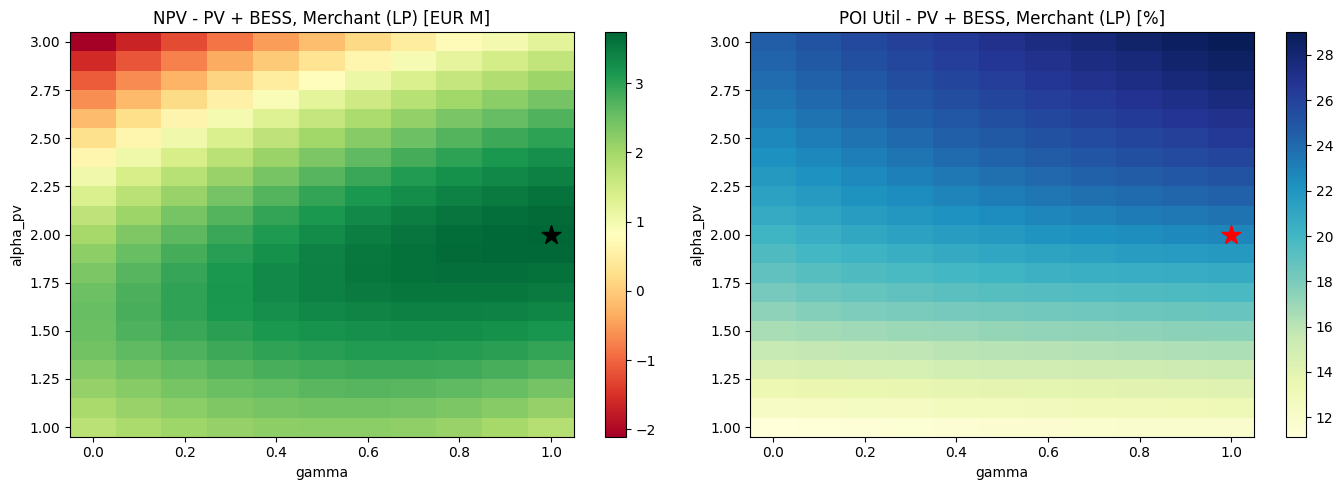

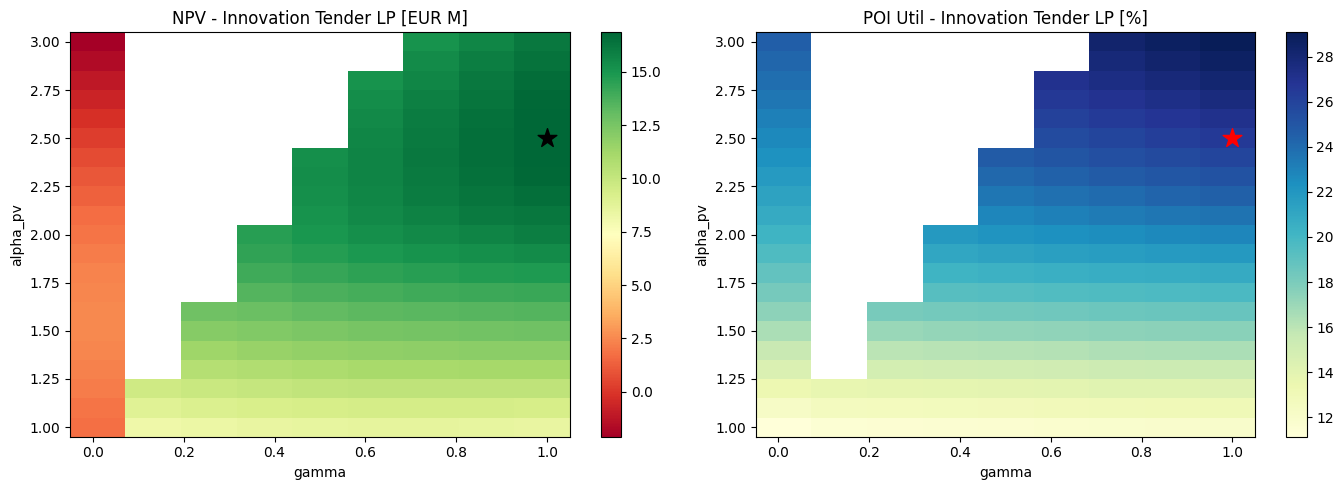

Saving results to data_processed/...
Saved: pv_bess_results.csv and pv_bess_results_innovation.csv


In [7]:
# Heatmaps for both scenarios
df_grid_basic = results_to_dataframe(results_lp_basic)
df_grid_innovation = results_to_dataframe(results_lp_innovation)

def _plot_heatmaps(df_grid, best, label, out_path):
    alpha_min = df_grid['alpha_pv'].min()
    alpha_max = df_grid['alpha_pv'].max()
    gamma_min = df_grid['gamma'].min()
    gamma_max = df_grid['gamma'].max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # NPV heatmap
    pivot_npv = df_grid.pivot(index='alpha_pv', columns='gamma', values='npv_eur')
    im1 = axes[0].imshow(
        pivot_npv.values / 1e6,
        cmap='RdYlGn',
        aspect='auto',
        origin='lower',
        extent=[gamma_min - 0.05, gamma_max + 0.05, alpha_min - 0.05, alpha_max + 0.05],
    )
    axes[0].scatter([best.gamma], [best.alpha_pv], c='k', s=200, marker='*')
    axes[0].set_xlabel('gamma')
    axes[0].set_ylabel('alpha_pv')
    axes[0].set_title(f'NPV - {label} [EUR M]')
    plt.colorbar(im1, ax=axes[0])

    # POI utilisation heatmap
    pivot_poi = df_grid.pivot(index='alpha_pv', columns='gamma', values='poi_utilisation')
    im2 = axes[1].imshow(
        pivot_poi.values * 100,
        cmap='YlGnBu',
        aspect='auto',
        origin='lower',
        extent=[gamma_min - 0.05, gamma_max + 0.05, alpha_min - 0.05, alpha_max + 0.05],
    )
    axes[1].scatter([best.gamma], [best.alpha_pv], c='r', s=200, marker='*')
    axes[1].set_xlabel('gamma')
    axes[1].set_ylabel('alpha_pv')
    axes[1].set_title(f'POI Util - {label} [%]')
    plt.colorbar(im2, ax=axes[1])

    plt.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()


_plot_heatmaps(
    df_grid_basic,
    best_lp_basic,
    label='PV + BESS, Merchant (LP)',
    out_path='../pv_bess_greenfield_heatmaps_merchant.png',
)

_plot_heatmaps(
    df_grid_innovation,
    best_lp_innovation,
    label='Innovation Tender LP',
    out_path='../pv_bess_greenfield_heatmaps_innovation.png',
)


# SAVE RESULTS
print("Saving results to data_processed/...")
if not (project_root / "data_processed").exists():
    (project_root / "data_processed").mkdir(parents=True, exist_ok=True)

df_grid_basic.to_csv(project_root / "data_processed" / "pv_bess_results.csv", index=False)
df_grid_innovation.to_csv(project_root / "data_processed" / "pv_bess_results_innovation.csv", index=False)
print('Saved: pv_bess_results.csv and pv_bess_results_innovation.csv')
